In [5]:
import numpy as np
import matplotlib.pyplot as plt

from cavity import Cavity
from bandstructure_class import BandStructureSim

import tidy3d as td
C0 = td.constants.C_0

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

---
## Finding geometries that are useful for the central defect and the mirror

We need to find a geometry for a unitcell that has the frequency of interest at the center of the bandgap. This unitcell will be used as the mirror cell. 

Then we need to find a geometry for which the frequency of interest intersect the lower (upper) band to create a dielectric (air) defect that sustains the central mode. 

Initializing eigensolver data
Computing 3 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 160 x 80.
Solving for 3 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 10, 0)
     (0, 0, 5)
Cell volume = 50
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.1, -0)
     (0, -0, 0.2)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,2,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.5,0.5,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -5.0625..5.0625, -2.5625..2.5625)
          bounding box (-0.25..0.25, -0.25..0.25, -5e+19..5e+19)
          shift object by (0, 0, -5)
          ellipsoid, center = (0,0,0)
               size (0.5,0.5,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          bounding box (-0.25..0.25, -0.25..0.25, -5e+19..5e+19)
          shift object by (0, 

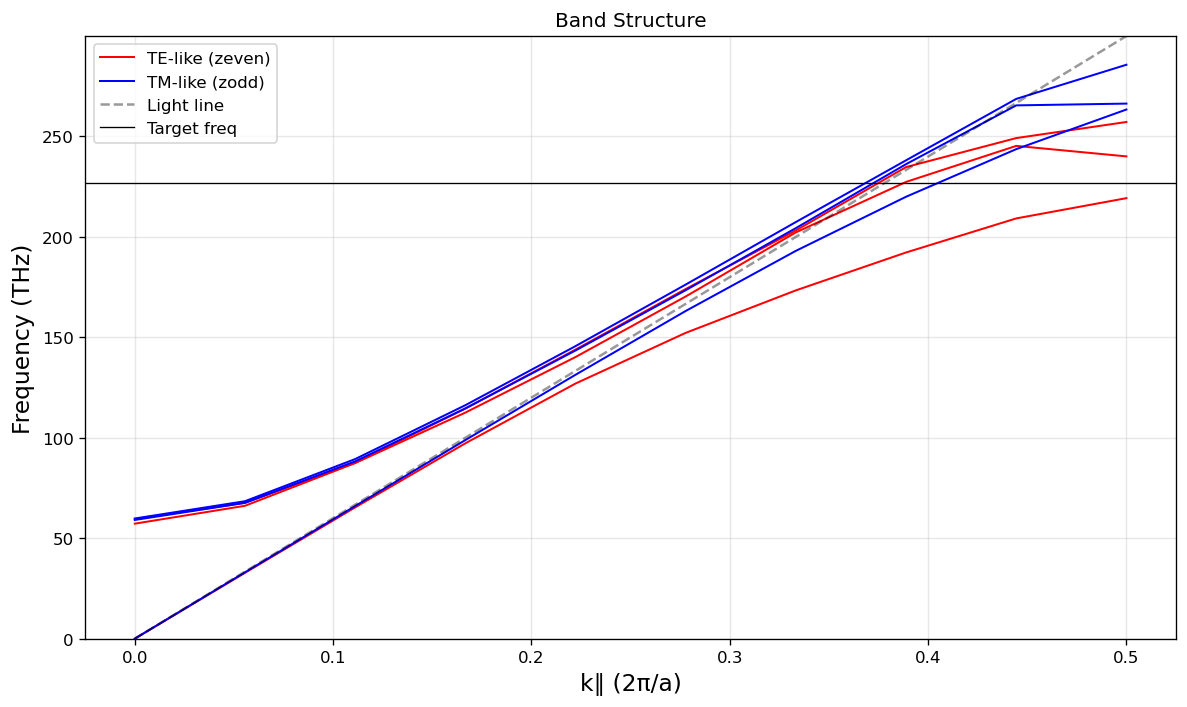

Initializing eigensolver data
Computing 3 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 175 x 90.
Solving for 3 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 10.6383, 0)
     (0, 0, 5.31915)
Cell volume = 56.5867
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.094, -0)
     (0, -0, 0.188)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,2.12766,0.531915)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.531915,0.531915,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -5.37994..5.37994, -2.71868..2.71868)
          bounding box (-0.265957..0.265957, -0.265957..0.265957, -5e+19..5e+19)
          shift object by (0, 0, -5.31915)
          ellipsoid, center = (0,0,0)
               size (0.531915,0.531915,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          bounding

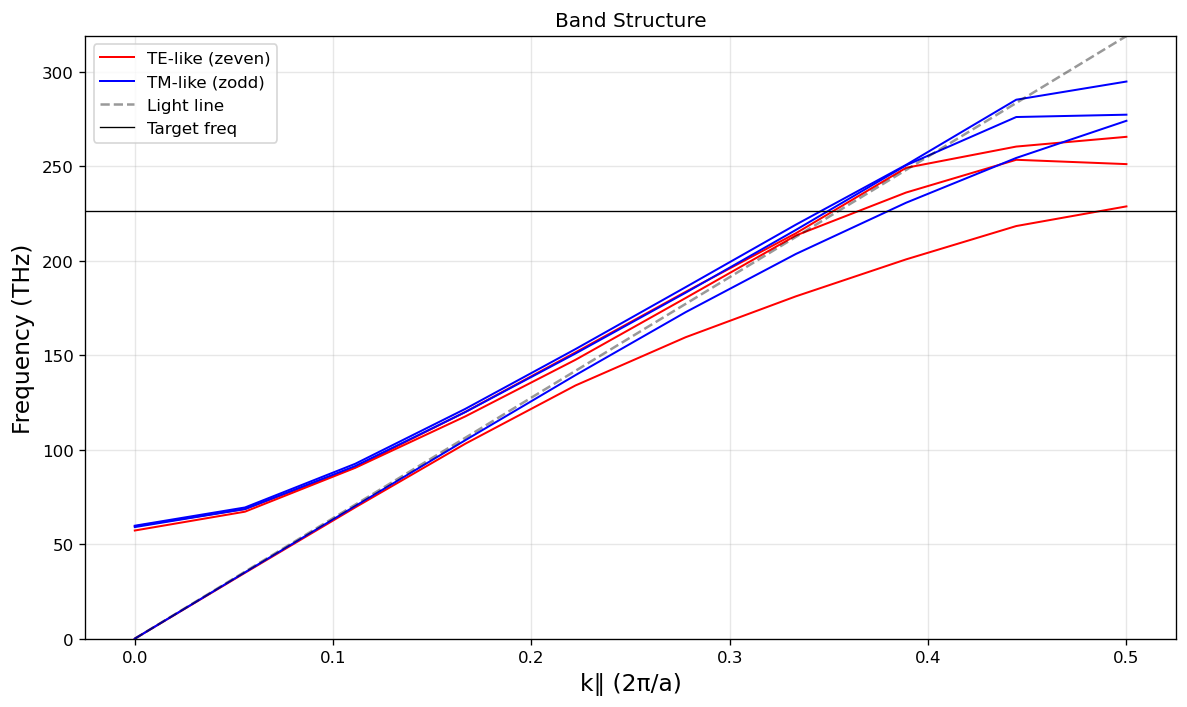

(<Figure size 1200x720 with 1 Axes>,
 <Axes: title={'center': 'Band Structure'}, xlabel='k∥ (2π/a)', ylabel='Frequency (THz)'>)

In [6]:
thickness = 0.25
wl0 = 1.324
freq0 = C0 / wl0


Lx = 0.5
Ly = 1
dx = 0.25
dy = 0.25

sim = BandStructureSim(
    Lx=Lx, Ly=Ly, thickness=thickness,
    geometry="ellipse", hole_params=[dx, dy],
    material_index=2.0, num_bands=3, resolution=16,
)
sim.run_bandstructure(k_min=0, k_max=0.5, n_k=8)
sim.plot_bands(units='THz', freq0_Hz=freq0)


Lx = 0.47
Ly = 1
dx = 0.25
dy = 0.25

sim = BandStructureSim(
    Lx=Lx, Ly=Ly, thickness=thickness,
    geometry="ellipse", hole_params=[dx, dy],
    material_index=2.0, num_bands=3, resolution=16,
)
sim.run_bandstructure(k_min=0, k_max=0.5, n_k=8)
sim.plot_bands(units='THz', freq0_Hz=freq0)

---
## Creating a Cavity with Custom Parameters

You can control three dictionaries:
- **`n_cells`** — number of cells per section (left taper, left mirror, defect, right mirror, right taper)
- **`parameters`** — lattice constants and hole dimensions for each section
- **`context`** — physical settings (frequency, thickness, width, medium, polarization, hole geometry, etc.)

Below we define a cavity with an intentional defect: the defect region has a smaller lattice constant and smaller holes to create a photonic-crystal bandgap defect mode.

Each section (linear taper, mirror or defect) of the nanobeam cavity is created such that the edge cells of the given section matches exactly the edge cels of the adjacent sections. For example:
- the leftmost cell of the defect matches the rightmost cell of the left mirror
- the righmost cell of the defect matches the leftmost cell of the right mirror
- the rightmost cell of the left linear taper matches the leftmost cell of the left mirror
- the leftmost cell of the right linear taper matches the rightmost cell of the right mirror

This means that if one does not want to simulate the taper, you can just set the number to 1 and it will just be an additional cell or the mirror. Or if one does not want to simulate a mirror, you can just set the number of mirror to 1 and it will match the last cell of the defect. At the moment the code cannot handle sections with zero components so the edge case is the following: 

```python
n_cells = {
    "N_left_taper":    1,
    "N_left_mirror":  1,
    "N_defect":       2,   
    "N_right_mirror": 1,
    "N_right_taper":   1,
}
```

The central defect cannot have less than 2 cells at the moment. 

This edge case is mostly due to small indexing problem in how the sections are created. 

Number of holes : 66
Position range  : [-14.500, 17.540] µm
Lattice range   : [0.470, 0.500] µm
Hole param shape: (66, 2)


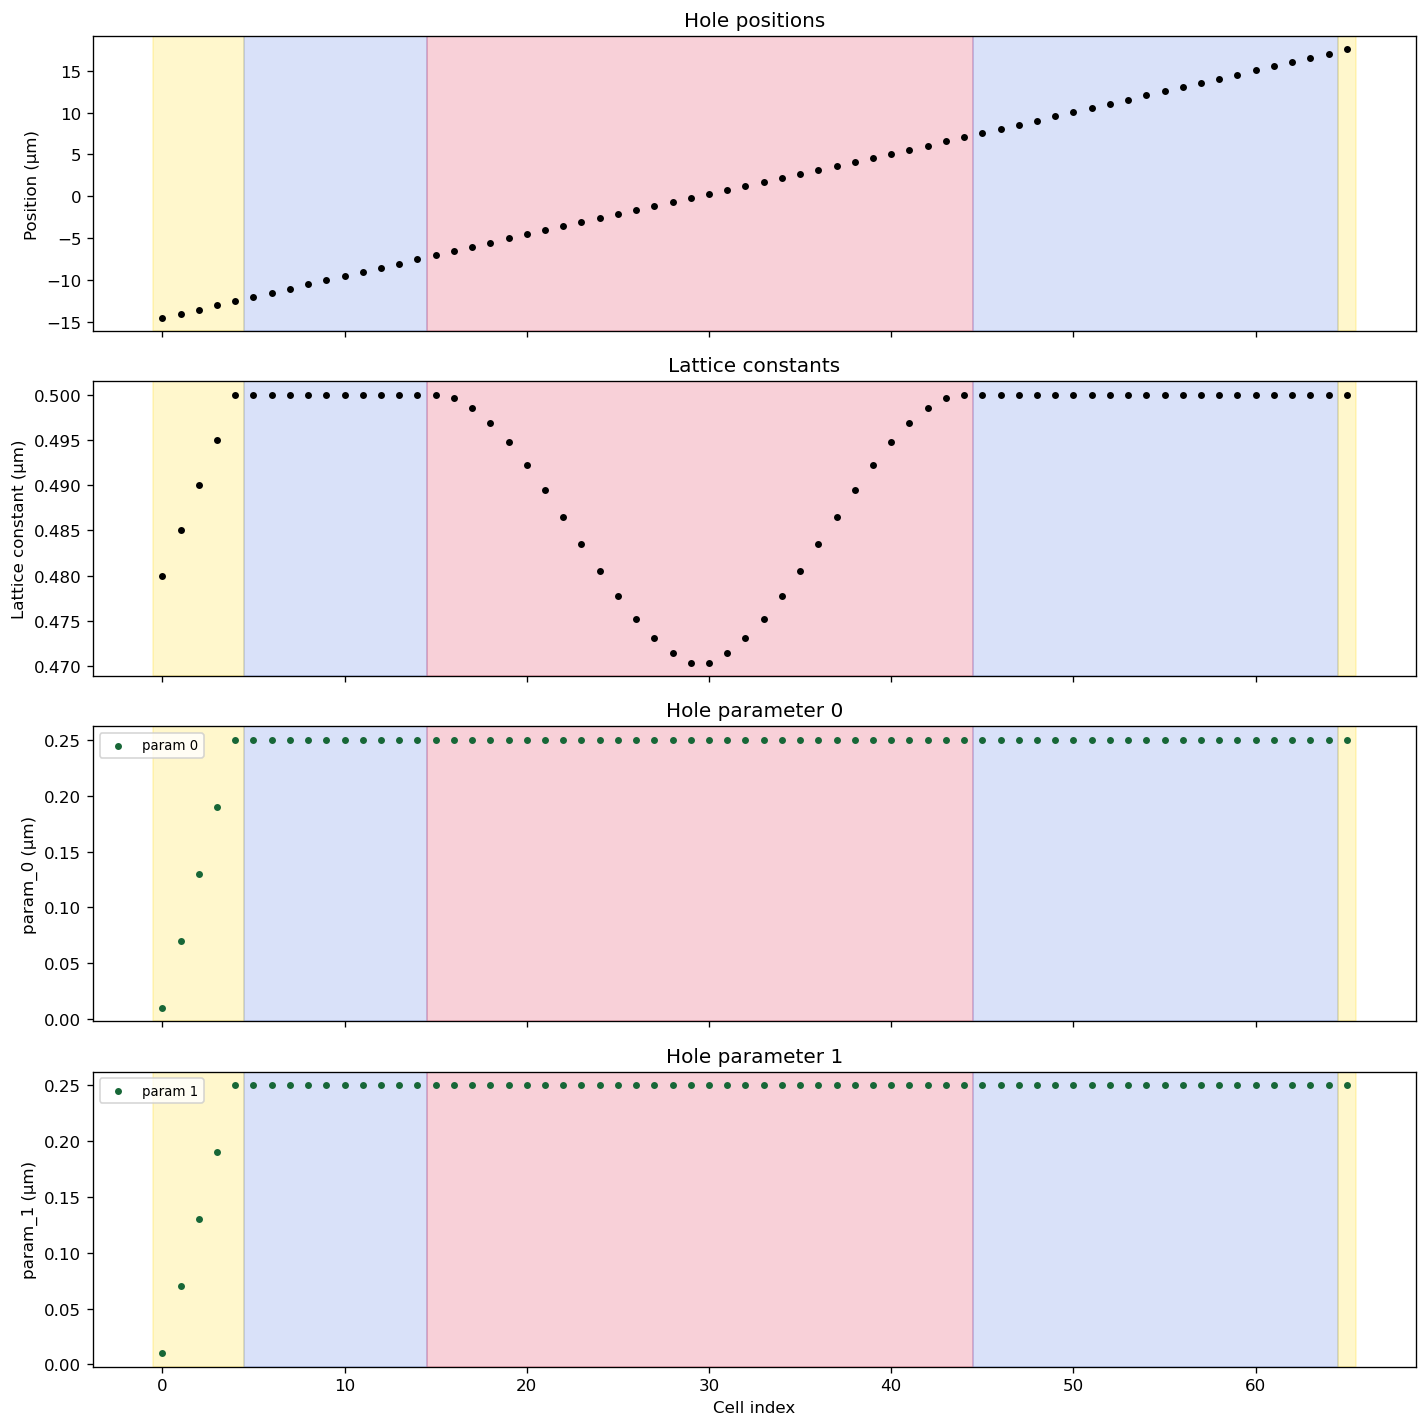

In [7]:
n_cells = {
    "N_left_taper":    5,
    "N_left_mirror":  10,
    "N_defect":       30,   # odd → includes a central cell
    "N_right_mirror": 20,
    "N_right_taper":   1,
}

parameters = {
    "parameters_taper_left":    {"lattice": 0.48, "hole_params": np.array([0.01, 0.01])},
    "parameters_mirrors_left":  {"lattice": 0.5, "hole_params": np.array([0.25, 0.25])},
    "parameters_defect":        {"lattice": 0.47,  "hole_params": np.array([0.25, 0.25])},
    "parameters_mirrors_right": {"lattice": 0.5, "hole_params": np.array([0.25, 0.25])},
    "parameters_taper_right":   {"lattice": 0.48, "hole_params": np.array([0.01, 0.01])},
}

wavelength = 1.324
freq0 = C0 / wavelength
fwidth = freq0 * 0.01

context = {
    "freq0":          freq0,       # centre frequency (1/µm)
    "fwidth":         fwidth,        # bandwidth
    "thickness":      0.25,       # slab thickness (µm)
    "width":          1,       # waveguide width (µm)
    "polarization":   "Ey",       # dipole polarization (TE-like)
    "medium":         2.0,          # material name (file-based dispersion) or refractive index
    "mode":           "dielectric",
    "sidewall_angle":  0,
    "geometry":       "ellipse",  # hole shape: 'ellipse' or 'square'
}

cavity = Cavity(n_cells=n_cells, parameters=parameters, context=context)

# Quick look at the raw data
layout = cavity.beam_layout
print(f"Number of holes : {len(layout['positions'])}")
print(f"Position range  : [{layout['positions'][0]:.3f}, {layout['positions'][-1]:.3f}] µm")
print(f"Lattice range   : [{layout['lattice'].min():.3f}, {layout['lattice'].max():.3f}] µm")
print(f"Hole param shape: {layout['hole_params'].shape}")

cavity.plot_beam_layout()

---
## How to choose the linear tapering? 

The last unitcell in the taper should be chosen such that you match the Bragg condition from the waveguide. As put in the Supp of [https://doi.org/10.1103/PhysRevLett.129.053603](https://doi.org/10.1103/PhysRevLett.129.053603): 

"The final lattice constant before the waveguide is chosen to match the periodicity of the standing wave formed by the incoming and reflected light as set by the effective refractive index of the waveguide and the optical frequency of the mode. In choosing this lattice constant, we aim to have the electric field nodes centered on the holes, so that the incident electric field is initially minimum when encountering an interface, thereby reducing scattering. The complementary view from the perspective of the outgoing cavity light is that the smooth reduction of these holes and the decreasing lattice constant effectively pushes the mode back into the dielectric band before closing the gap entirely."

Therefore the code finds out the n_effective of the waveguide and find the periodicity of the Bragg condition. Then you should linear taper with smaller holes with that specific perioditcity to close the bandgap. 

```python
n_eff = mode_data.n_eff.values.flatten()
k_wg = 2 * np.pi * n_eff * self.context["freq0"] / C0
a_last = self.wl0 / (2 * n_eff)
```

---
## Accessing Sub-Components

Each section of the cavity is its own object. You can inspect them independently.

In [8]:
# Defect taper
defect = cavity.defect
print(f"Defect cells     : {defect.n_defect}")
print(f"Has central cell : {defect.has_center}")
print(f"Half count       : {defect.n_half}")
print(f"Defect positions : {defect.defect_layout['positions']}")
print()

# Left mirror
ml = cavity.mirror_left
print(f"Left mirror cells: {ml.n_mirror}")
print(f"Lattice (uniform): {ml.mirror_layout['lattice'][0]:.3f} µm")
print()

# Left taper
tl = cavity.taper_left
print(f"Left taper cells : {tl.n_taper}")
print(f"Taper lattices   : {tl.taper_layout['lattice']}")

Defect cells     : 30
Has central cell : False
Half count       : 15
Defect positions : [-7.04       -6.54019111 -6.04111111 -5.5434     -5.04759111 -4.55411111
 -4.06328    -3.57531111 -3.09031111 -2.60828    -2.12911111 -1.65259111
 -1.1784     -0.70611111 -0.23519111  0.23519111  0.70611111  1.1784
  1.65259111  2.12911111  2.60828     3.09031111  3.57531111  4.06328
  4.55411111  5.04759111  5.5434      6.04111111  6.54019111  7.04      ]

Left mirror cells: 10
Lattice (uniform): 0.500 µm

Left taper cells : 5
Taper lattices   : [0.5   0.495 0.49  0.485 0.48 ]


---
## Building the FDTD Simulation

`build_simulation()` performs several steps:
1. Resolves the material (dispersion fitting or constant index)
2. Computes the simulation domain and PML boundaries
3. Places the point-dipole source and all monitors
4. Constructs the nanobeam geometry (waveguide + holes)
5. Runs a cross-sectional mode solve to find the effective index

You can pass `plot=True` to visualize intermediate steps (dispersion fit, mode solve).

14:24:50 PDT WARNING: Use the remote mode solver with subpixel averaging for    
             better accuracy through 'tidy3d.web.run(...)' or the deprecated    
             'tidy3d.plugins.mode.web.run(...)'.                                

             WARNING: Mode field at frequency index 0, mode index 1 does not    
             decay at the plane boundaries.                                     

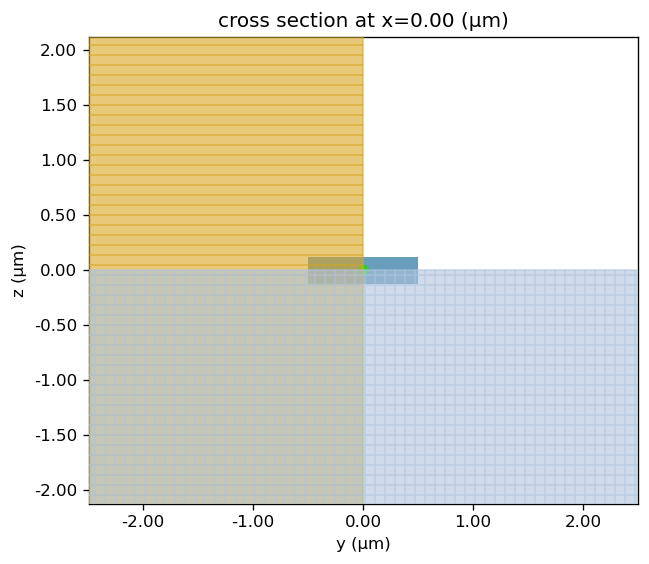

                         wavelength     n eff  k eff  TE (Ey) fraction  \
f            mode_index                                                  
2.264293e+14 0                1.324  1.455148    0.0          0.992163   
             1                1.324  0.984193    0.0          0.997375   

                         wg TE fraction  wg TM fraction  mode area  
f            mode_index                                             
2.264293e+14 0                 0.864936        0.804868   0.458768  
             1                 0.988178        0.977998  12.380229  
mode n_eff: [1.45514805 0.98419347]
mode k_wg: [6.90556258 4.67059662]
mode a_last: [0.45493653 0.67263198]


In [9]:
cavity = Cavity(
    n_cells=n_cells,
    parameters=parameters,
    context=context,  
)

sim = cavity.build_simulation(
    grid_size_override=(0.02, 0.02, 0.02),  # coarser mesh for quick testing
    num_modes=2,
    plot=True,  # show mode solve results
)

print("mode n_eff:", sim.n_eff)
print("mode k_wg:", sim.k_wg)
print("mode a_last:", sim.a_last)

### Visualize the simulation domain

`plot_simulation()` shows:
- Hole positions, lattice constants, and hole parameters vs. cell index
- A zoomed-in view of the defect region
- Three orthogonal cross-sections of the full simulation domain (top, side, cross-section)

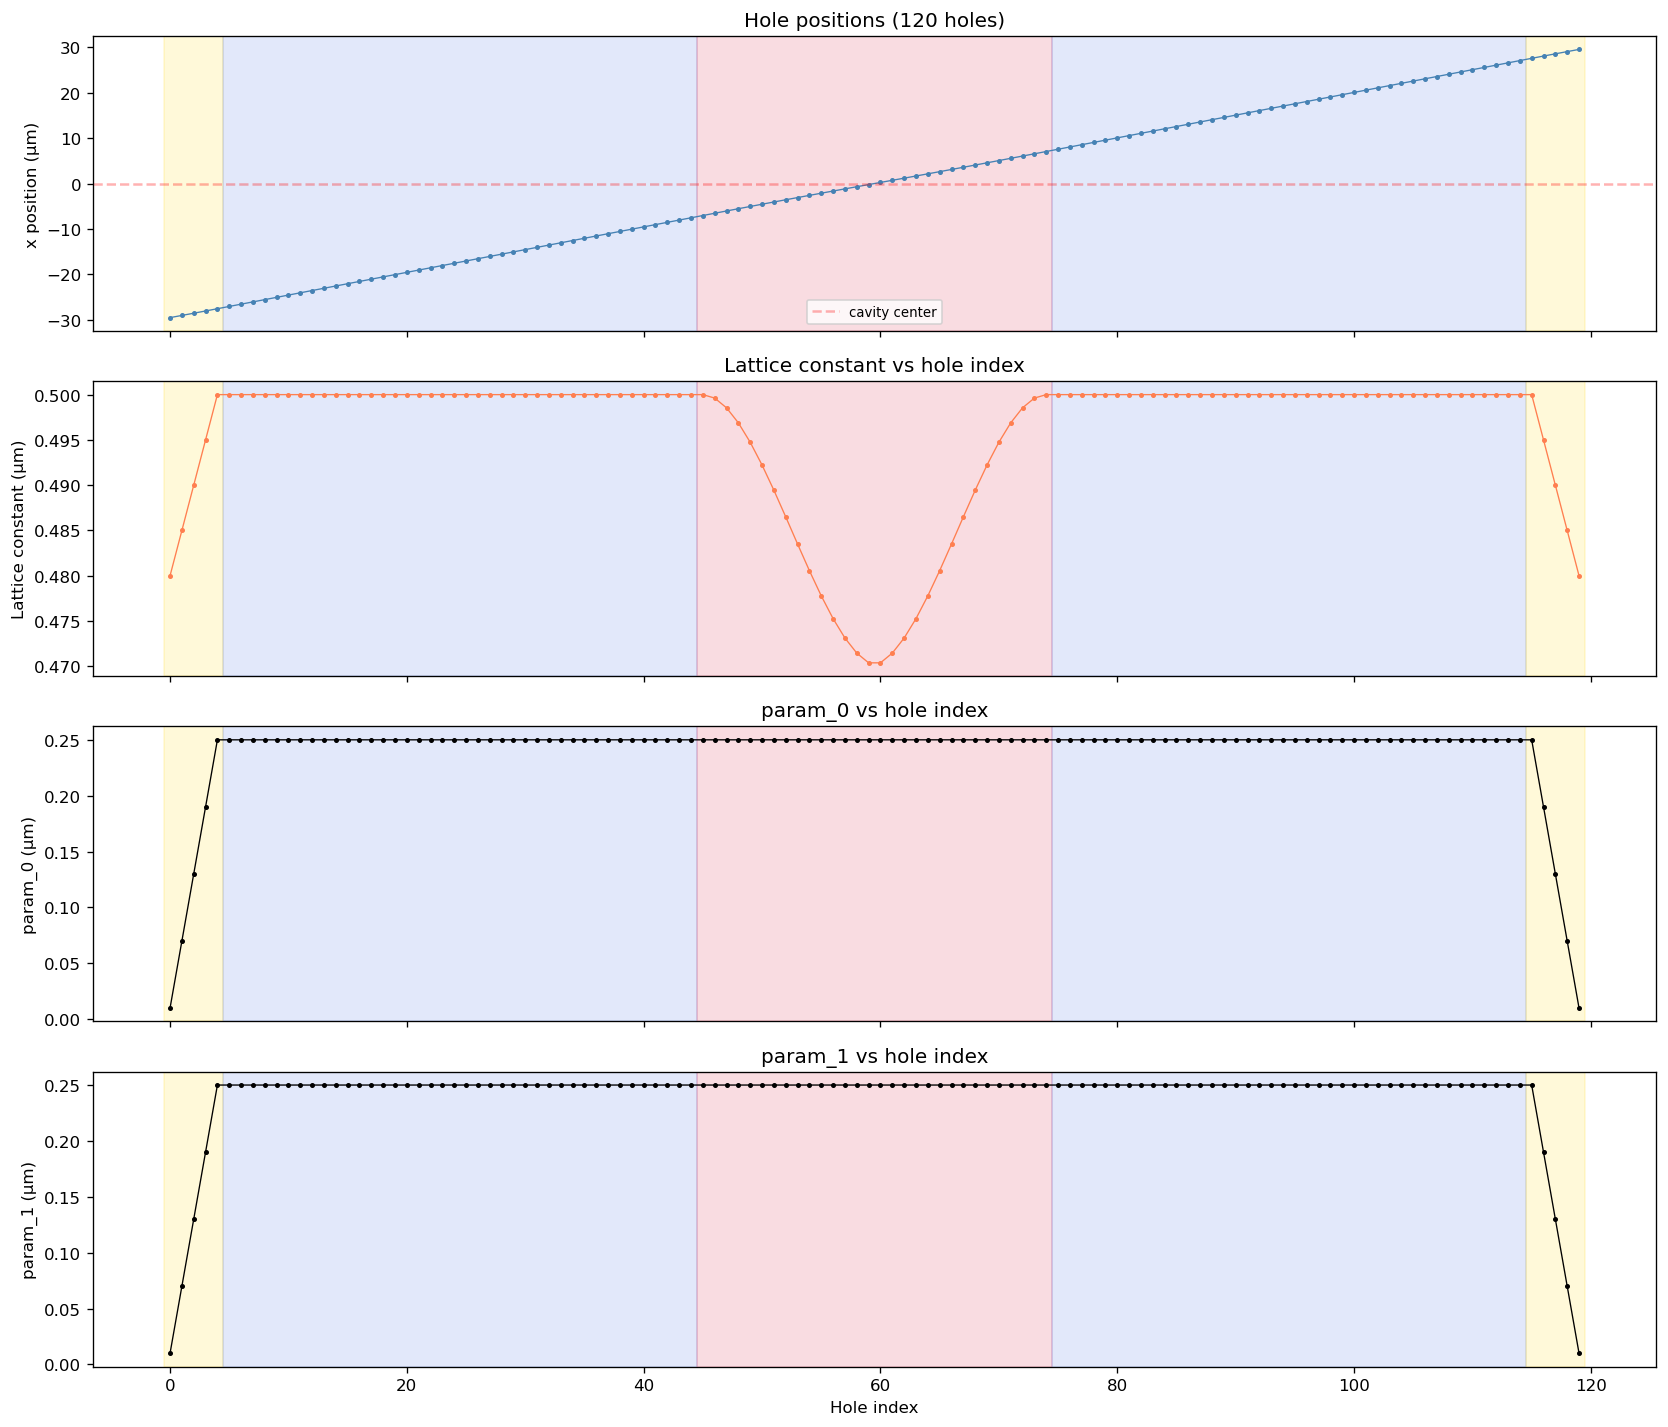

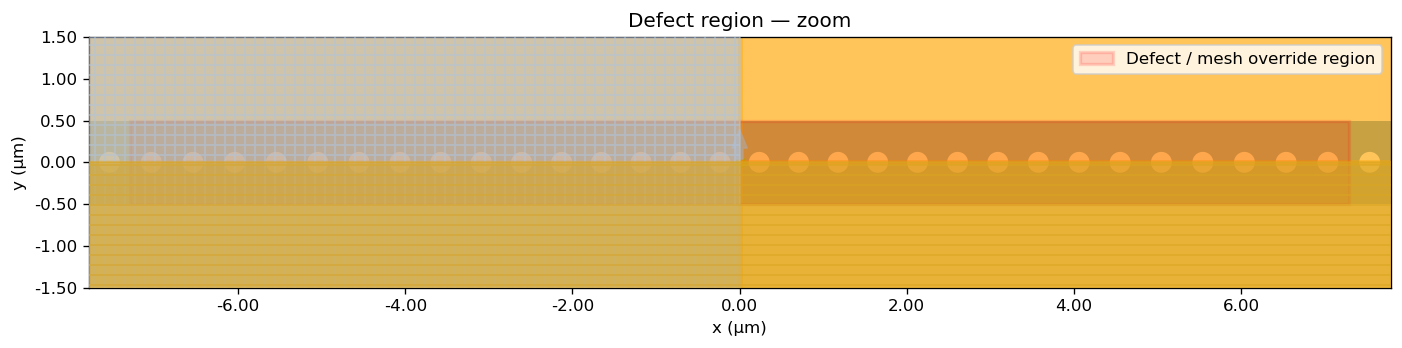

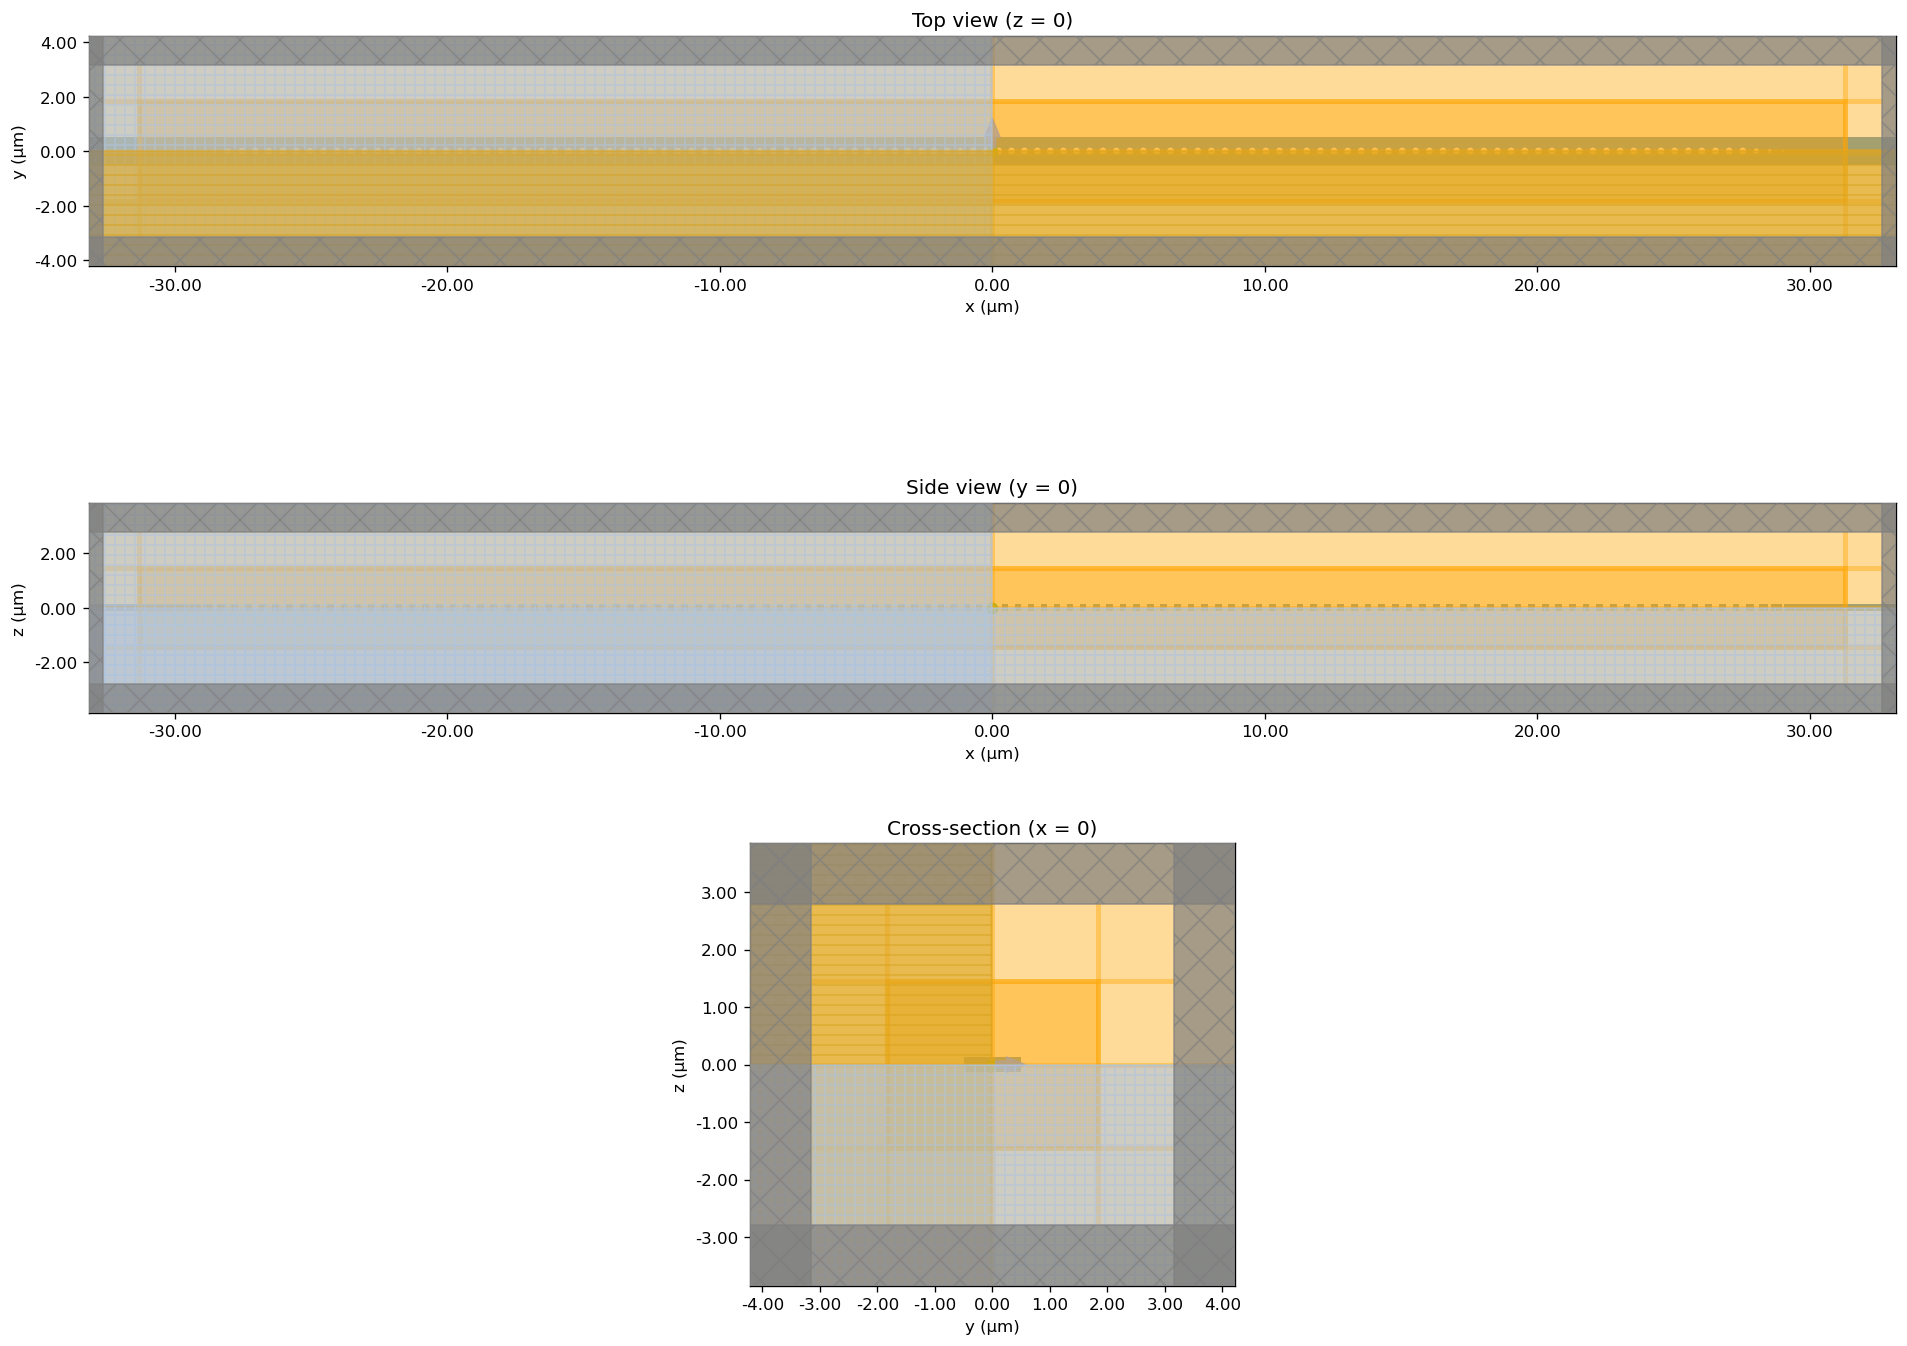

In [7]:
cavity.plot_simulation()

### Inspect simulation properties

In [8]:
sim_obj = cavity.simulation

print(f"Simulation center : {sim_obj.sim_center}")
print(f"Simulation size   : {sim_obj.sim_size}")
print(f"Run time          : {sim_obj.run_time * 1e12:.1f} ps")
print(f"Effective indices : {sim_obj.n_eff}")
print(f"Wavevector k_wg   : {sim_obj.k_wg}")
print(f"Number of monitors: {len(sim_obj.monitors)}")
print(f"Symmetry          : {sim_obj.sim.symmetry}")

Simulation center : (np.float64(0.0), 0.0, 0.0)
Simulation size   : (np.float64(65.28261306532663), 6.3226130653266335, 5.5726130653266335)
Run time          : 5.0 ps
Effective indices : [1.45514805 0.98419347]
Wavevector k_wg   : [6.90556258 4.67059662]
Number of monitors: 20
Symmetry          : (1, -1, 1)


---
## Running the Simulation on Tidy3D Cloud

The `run()` method uploads and runs the simulation on Tidy3D's cloud servers. You need a valid Tidy3D API key configured.

```python
import tidy3d.web as web
web.configure("YOUR_API_KEY")  # one-time setup
```

In [35]:
sim_obj.upload(directory="results", save_name="tutorial_cavity")
sim_obj.estimate_cost()
sim_data = sim_obj.run(directory="results", save_name="tutorial_cavity")

23:48:26 PDT Created task 'tutorial_cavity' with task_id                        
             'fdve-8872a2f6-5e38-4c7b-b614-02a7b65a67e0' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=511143;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8872a2f6-5e38-4c7b-b614-02a7b65a67e0\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=52009;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8872a2f6-5e38-4c7b-b614-02a7b65a67e0\taskId]8;;\]8;id=511143;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8872a2f6-5e38-4c7b-b614-02a7b65a67e0\=]8;;\]8;id=711721;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8872a2f6-5e38-4c7b-b614-02a7b65a67e0\fdve]8;;\]8;id=511143;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8872a2f6-5e38-4c7b-b614-02a7b65a67e0\-8872a2f6-5e3]8;;\
             ]8;id=511143;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8872a2f6-5e38-4c7b-b614-02a7b65a67e0\8-4c7b-b614-02a7b65a67e0']8;;\.

             Task folder: ]8;id=464886;https://tidy3d.simulation.cloud/folders/folder-7f7e07d7-47f7-49a3-80b7-1bc50dfb9707\'results']8;;\.

Output()

23:48:28 PDT Maximum FlexCredit cost: 0.160. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

23:51:10 PDT View simulation result at                                          
             ]8;id=85274;https://tidy3d.simulation.cloud/workbench?taskId=fdve-849b37d8-0d9f-4124-9bbd-604944d37cd0\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=7912;https://tidy3d.simulation.cloud/workbench?taskId=fdve-849b37d8-0d9f-4124-9bbd-604944d37cd0\taskId]8;;\]8;id=85274;https://tidy3d.simulation.cloud/workbench?taskId=fdve-849b37d8-0d9f-4124-9bbd-604944d37cd0\=]8;;\]8;id=369598;https://tidy3d.simulation.cloud/workbench?taskId=fdve-849b37d8-0d9f-4124-9bbd-604944d37cd0\fdve]8;;\]8;id=85274;https://tidy3d.simulation.cloud/workbench?taskId=fdve-849b37d8-0d9f-4124-9bbd-604944d37cd0\-849b37d8-0d9]8;;\
             ]8;id=85274;https://tidy3d.simulation.cloud/workbench?taskId=fdve-849b37d8-0d9f-4124-9bbd-604944d37cd0\f-4124-9bbd-604944d37cd0']8;;\.

Output()

23:51:32 PDT loading simulation from results/tutorial_cavity.hdf5

             WARNING: Simulation final field decay value of 0.027 is greater    
             than the simulation shutoff threshold of 1e-05. Consider running   
             the simulation again with a larger 'run_time' duration for more    
             accurate results.                                                  

Results saved: results/tutorial_cavity.hdf5


---
## Post-Processing (after running)

All analysis methods below require simulation data. If you've already run a simulation and have an HDF5 file, you can reload it:

```python
cavity_loaded = Cavity.from_simulation("results/tutorial_cavity.hdf5")
```

### Resonance Analysis

Uses the `ResonanceFinder` plugin to identify cavity modes from the point-monitor time signals.

In [36]:
# --- Uncomment after running the simulation ---
df, combined_signal = cavity.simulation.analyse_resonances()
print(df.sort_values('Q', ascending=False).head(5))
print(f"\nBest Q  : {cavity.simulation.Q:.0f}")
print(f"Freq    : {cavity.simulation.resonant_frequency:.4e} (1/µm)")
print(f"Wavelength: {abs(df.sort_values('Q').iloc[-1]['wl']):.2f} nm")

                     decay             Q      amplitude     phase     error  \
freq                                                                          
2.251235e+14  2.883013e+07  2.453150e+07  149860.778807  0.673565  0.004203   

                       wl  
freq                       
2.251235e+14  1331.680157  

Best Q  : 24531500
Freq    : 2.2512e+14 (1/µm)
Wavelength: 1331.68 nm


### Energy Density and Mode Volume

In [38]:
# --- Uncomment after running the simulation ---
energy_density, eps = cavity.simulation.get_energy_density()
Vmode = cavity.simulation.mode_volume()

Mode volume: 1.4052 (λ/n)³


### Directional Q-Factors

Computes Q from flux monitors on each face of the simulation domain, giving loss breakdown by direction.

In [40]:
# --- Uncomment after running the simulation ---
Q_dir = cavity.simulation.directional_Q()

Q_+x = 2997.25 M
Q_-x = 2997.25 M
Q_+y = 5.53 M
Q_-y = 5.53 M
Q_+z = 3.07 M
Q_-z = 3.07 M
Q_total = 0.99 M


### Full Analysis (all-in-one)

Runs resonance analysis, energy density, mode volume, directional Q, and prints a summary with the Purcell factor estimate.

In [41]:
# --- Uncomment after running the simulation ---
cavity.full_analysis()

=== Resonance Analysis ===
                     decay             Q      amplitude     phase     error  \
freq                                                                          
2.251235e+14  2.883013e+07  2.453150e+07  149860.778807  0.673565  0.004203   

                       wl  
freq                       
2.251235e+14  1331.680157  

Best resonance: f = 2.2512e+14 Hz, Q = 24531500

=== Energy Density ===
Energy density computed.

=== Mode Volume ===
Mode volume: 1.4052 (λ/n)³

=== Directional Q ===
Q_+x = 2997.25 M
Q_-x = 2997.25 M
Q_+y = 5.53 M
Q_-y = 5.53 M
Q_+z = 3.07 M
Q_-z = 3.07 M
Q_total = 0.99 M

=== Summary ===
  Q (resonance finder): 24531500
  Q (directional total): 0.99 M
  Mode volume: 1.4052 (λ/n)³
  Purcell factor estimate: 1326620.3


### Field Plots

`plot_results()` shows |E| and |H| field components on the three profile monitors at the final time step.

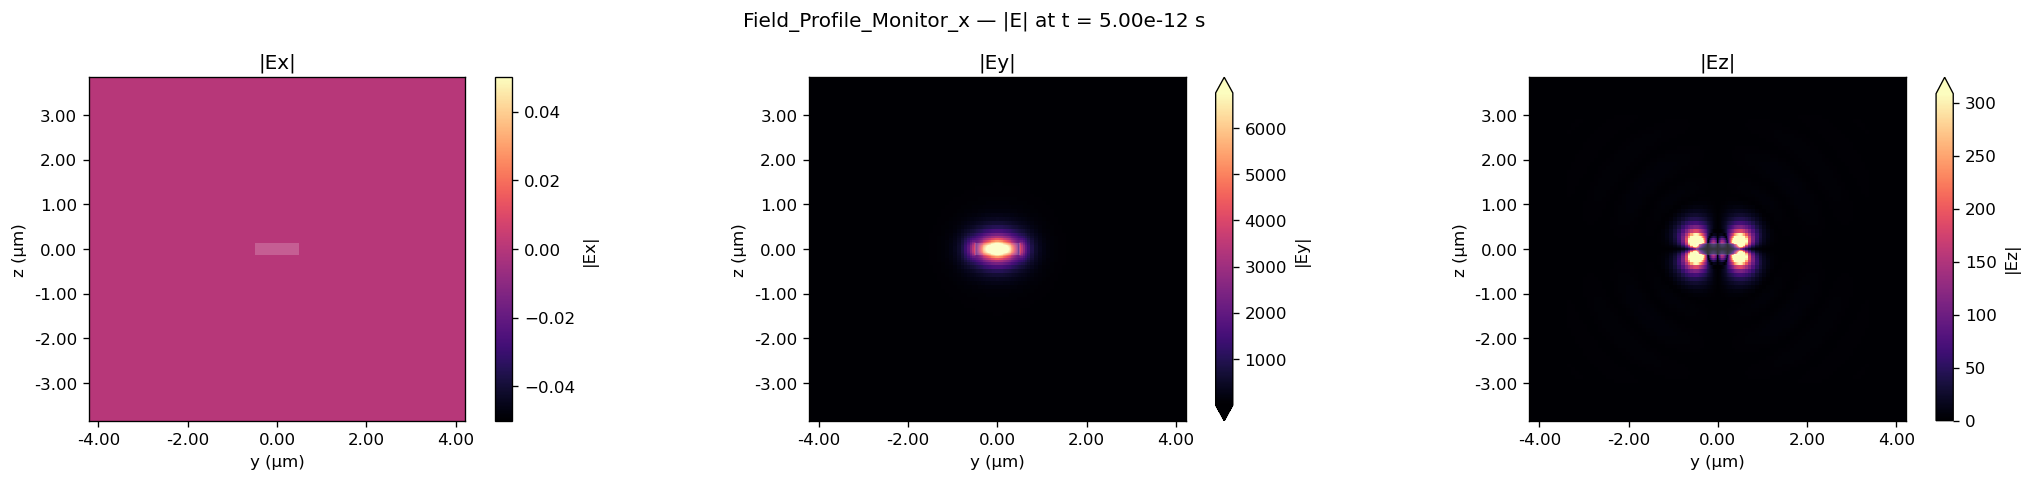

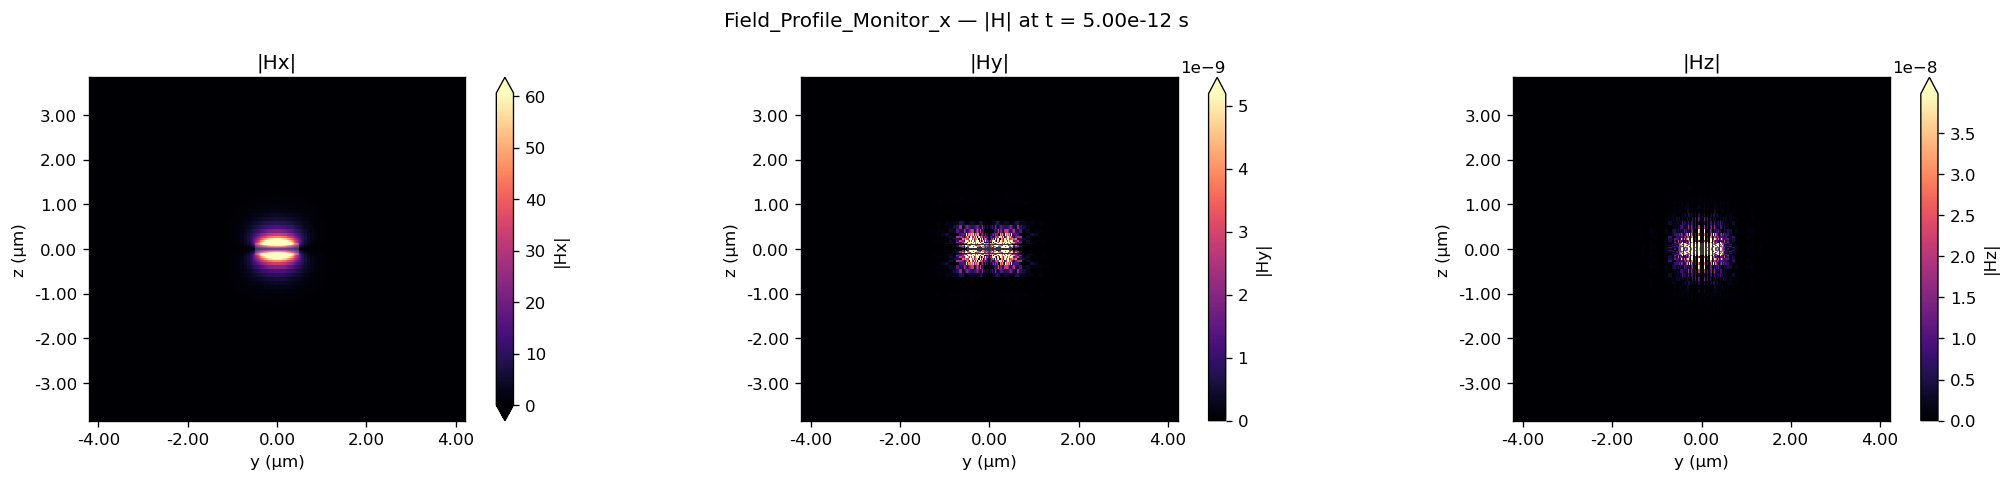

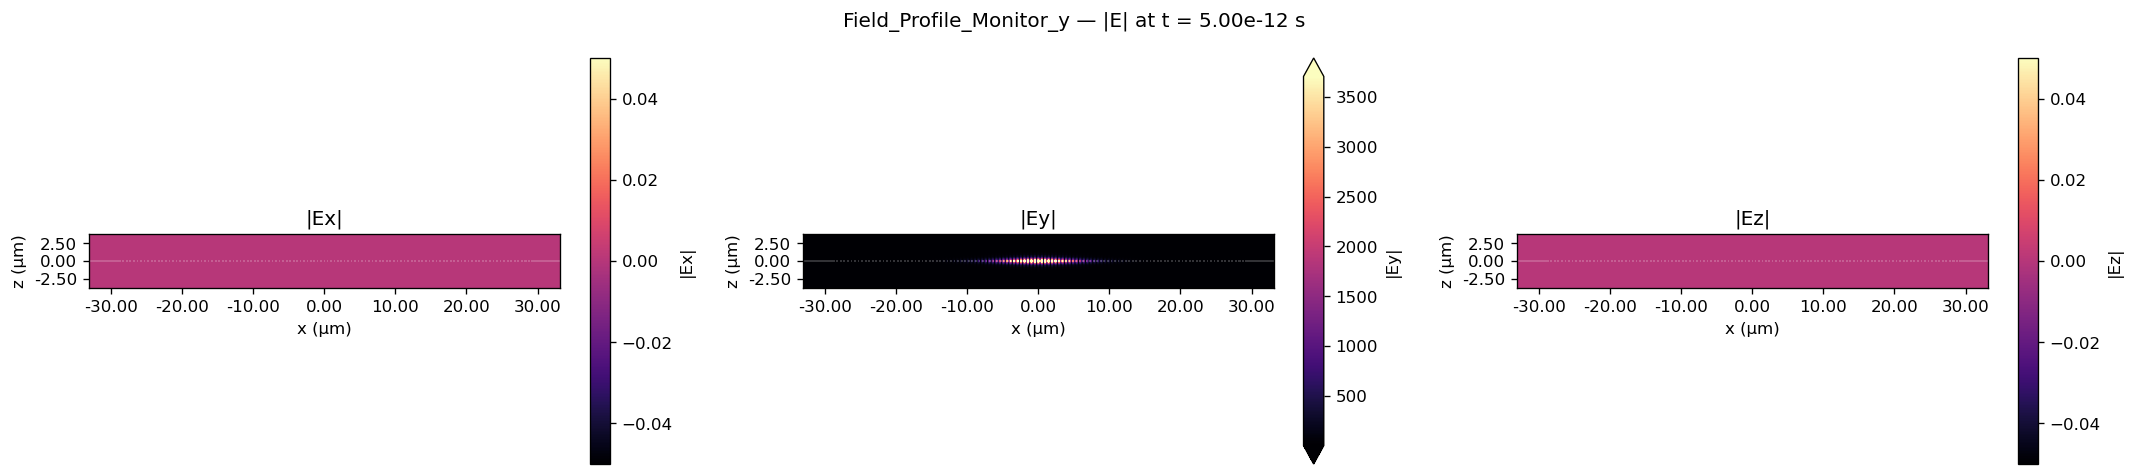

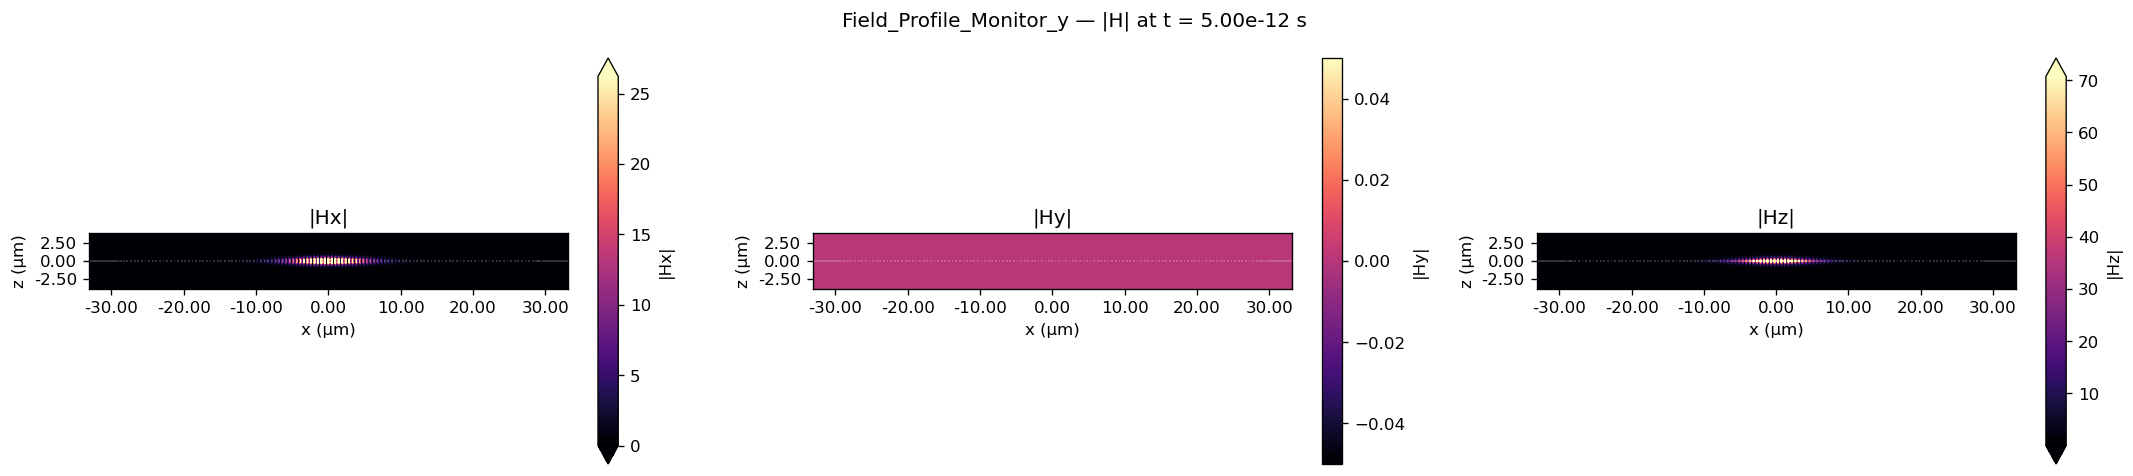

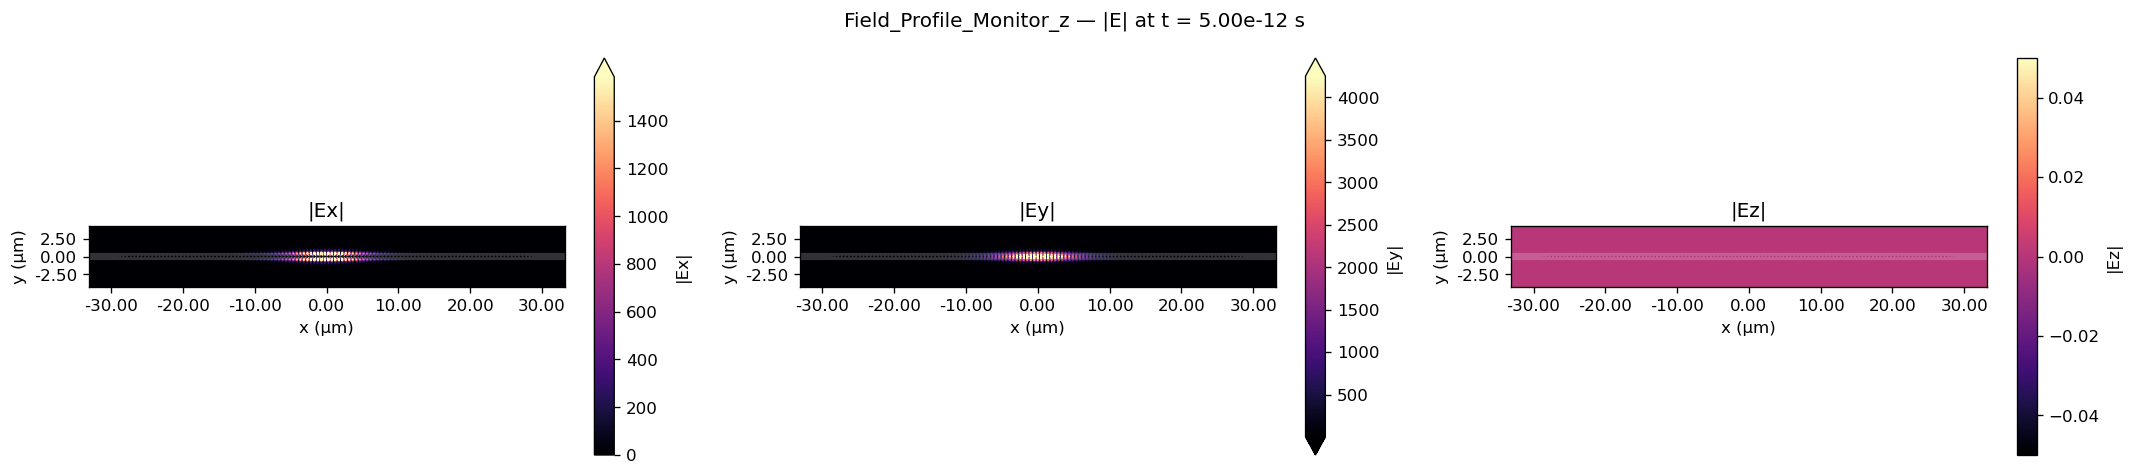

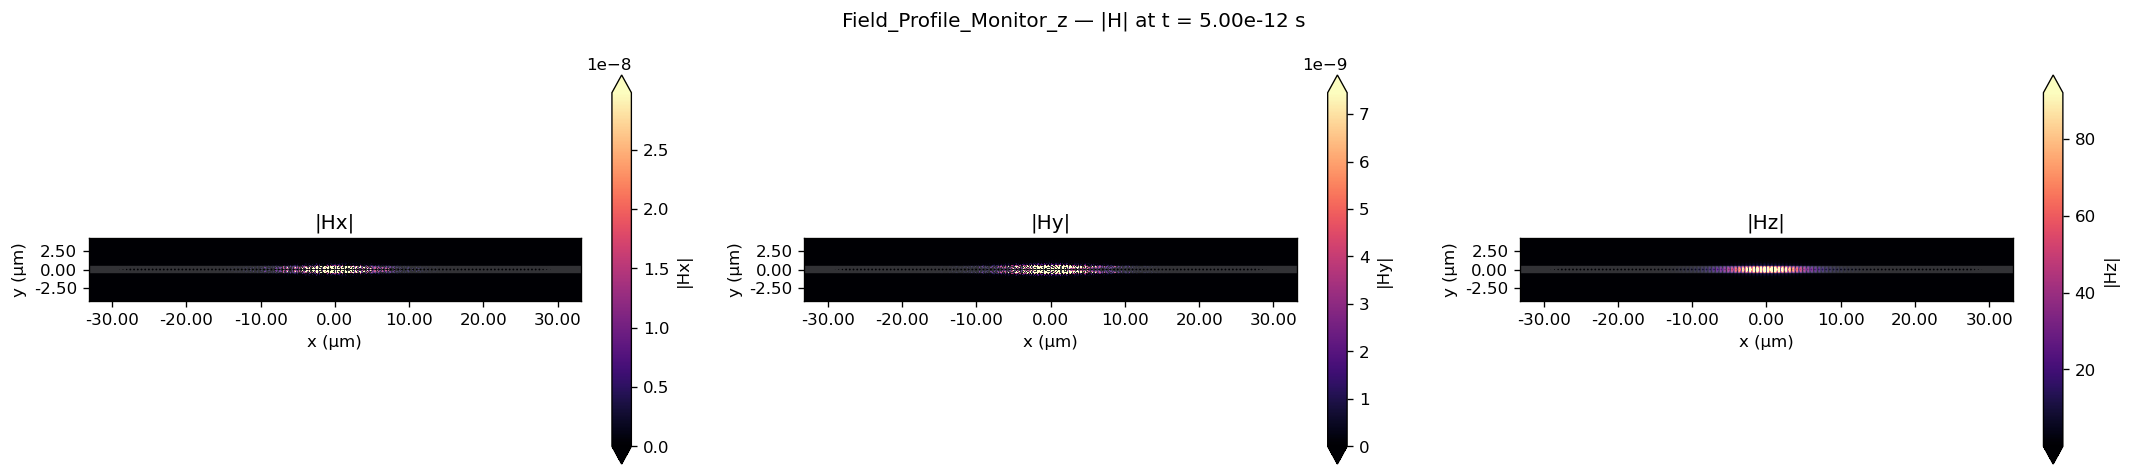

In [42]:
# --- Uncomment after running the simulation ---
cavity.simulation.plot_results()

### Mode Profile with Gaussian Fit

Extracts the 1D field profile along the beam axis and fits a Gaussian-modulated sinusoid. This gives the mode's spatial extent (σ) and effective wavevector.

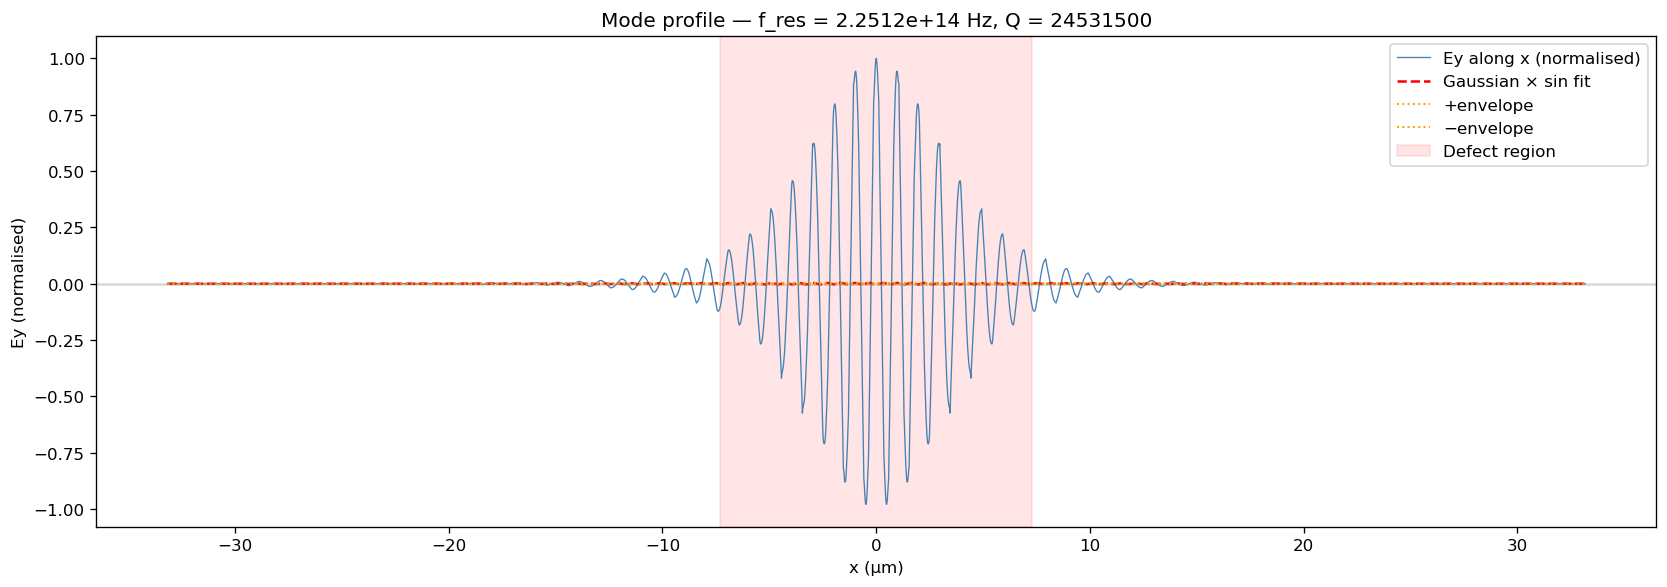

Fit: A=0.0032, σ=10.9568 µm, k=9.60 rad/µm, φ=-1.571
Mode confinement sigma = 10.957 µm


In [43]:
# --- Uncomment after running the simulation ---
popt, pcov = cavity.simulation.plot_mode_along_beam()
A, sigma, k, phi, offset = popt
print(f"Mode confinement sigma = {abs(sigma):.3f} µm")

### Field Animation

Creates an animated GIF of a field component on a 2D monitor over time.

GIF saved: cavity_Ey_z.gif (60 frames, 15 fps, 120 dpi)


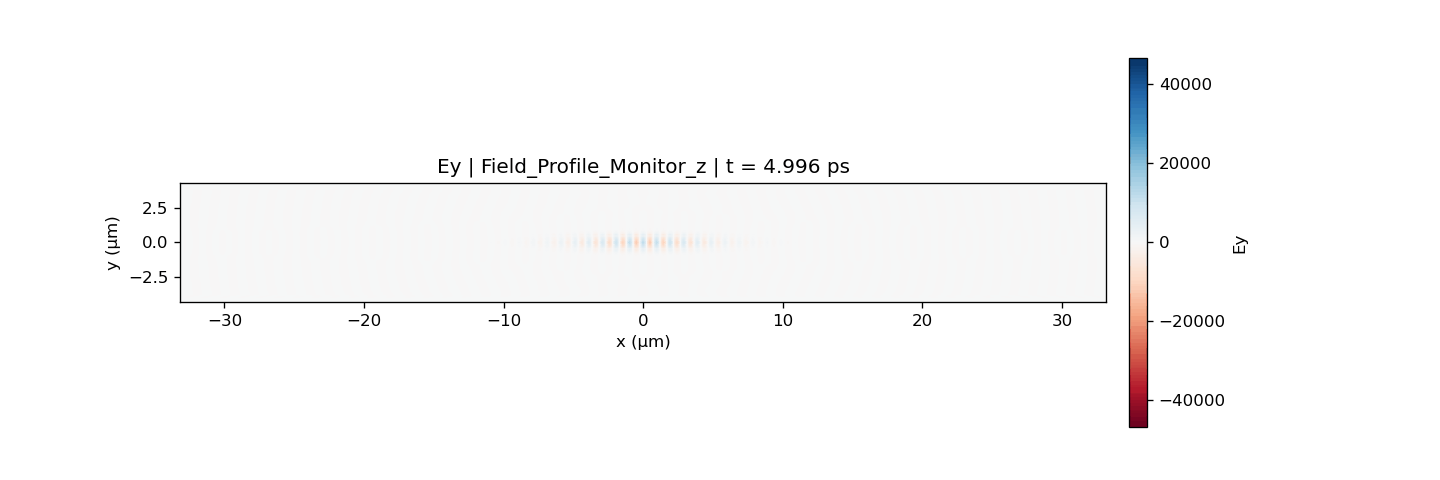

In [44]:
# --- Uncomment after running the simulation ---
cavity.animate_field(
    monitor_name="Field_Profile_Monitor_z",
    field_component="Ey",
    output_path="cavity_Ey_z.gif",
    fps=15,
    dpi=120,
    n_frames=60,
)

from IPython.display import Image
Image(filename="cavity_Ey_z.gif")

---
## Saving and Loading Cavities

### Save/load parameters (JSON)

In [9]:
# Save parameters to JSON
cavity.save_params(directory="saved_cavities", save_name="my_cavity")

# Reload from JSON
cavity_reloaded = Cavity.from_params("saved_cavities/my_cavity_parameters.json")
print(cavity_reloaded)

Parameters saved: saved_cavities/my_cavity_parameters.json
Cavity(120 cells: LT=5, LM=40, D=30, RM=40, RT=5)


### Load from simulation HDF5

After running, the simulation data includes the cavity definition in its metadata. You can fully reconstruct the `Cavity` (with simulation data attached) from the HDF5 file.

In [9]:
# --- Uncomment if you have a completed simulation file ---
cavity_from_sim = Cavity.from_simulation("results/tutorial_cavity.hdf5")
print(cavity_from_sim)
print(f"Q factor: {cavity_from_sim.simulation.Q:.0f}")

Cavity(120 cells: LT=5, LM=40, D=30, RM=40, RT=5)
Q factor: 24531500


---
## GDS Export with gdsfactory

If `gdsfactory` is installed, you can export the cavity layout to a GDS file for fabrication.

```bash
pip install gdsfactory
```

Component name: Unnamed_0
Ports: ['left', 'right']
GDS written: cavity_test.gds


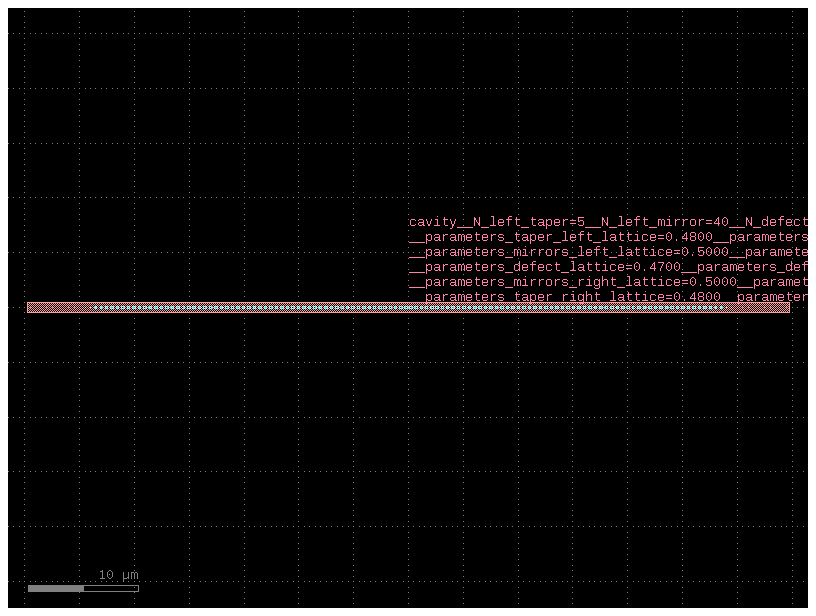

In [ ]:
import gdsfactory as gf
gf.kcl.clear()
gf.gpdk.PDK.activate()

component = cavity.render_gdsfactory(
    layer=(1, 0),
    hole_layer=(2, 0),
    n_pts=128,
    waveguide_extension=5.0,
)
component.plot()
print(f"Component name: {component.name}")
print(f"Ports: {[p.name for p in component.ports]}")

# Write to GDS — use a unique top-cell name to avoid collisions on re-run
top = gf.Component("cavity_export")
top.add_ref(component)
top.write_gds("cavity_test.gds")
print("GDS written: cavity_test.gds")


---
## Exploring Hole Geometries

The `hole_polygon_2d` function generates 2D polygons for different hole shapes. You can visualise them directly.

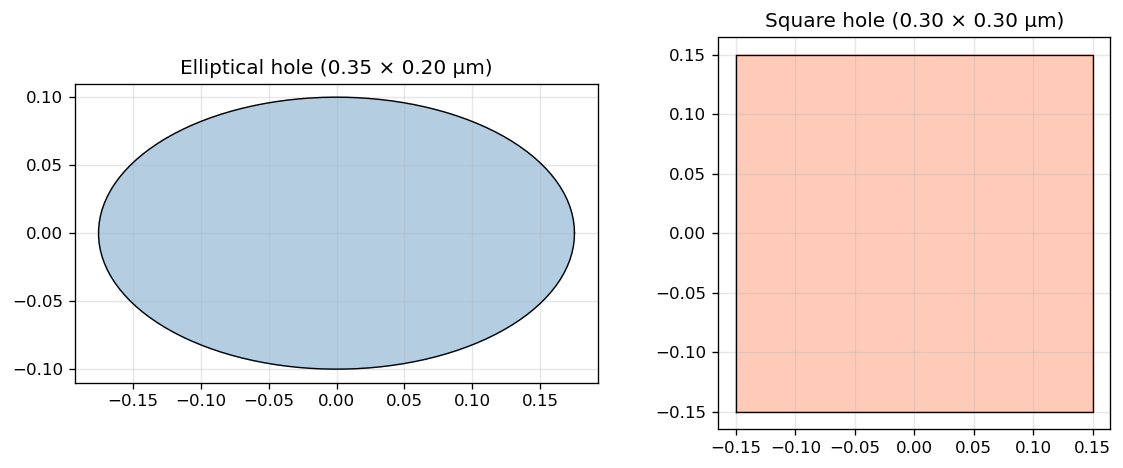

In [18]:
from hole import hole_polygon_2d

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Elliptical hole
poly_ellipse = hole_polygon_2d("ellipse", [0.35, 0.20], n_pts=128)
axes[0].fill(poly_ellipse[:, 0], poly_ellipse[:, 1], alpha=0.4, color='steelblue')
axes[0].plot(poly_ellipse[:, 0], poly_ellipse[:, 1], 'k-', linewidth=0.8)
axes[0].set_title('Elliptical hole (0.35 × 0.20 µm)')
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

# Square hole
poly_square = hole_polygon_2d("square", [0.30, 0.30])
axes[1].fill(poly_square[:, 0], poly_square[:, 1], alpha=0.4, color='coral')
axes[1].plot(poly_square[:, 0], poly_square[:, 1], 'k-', linewidth=0.8)
axes[1].set_title('Square hole (0.30 × 0.30 µm)')
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Descriptive Cavity Name

The `get_name()` method generates a machine-readable identifier encoding all cell counts and parameters — useful for batch sweeps.

In [20]:
print(cavity.get_name())

cavity__N_left_taper=8__N_left_mirror=15__N_defect=21__N_right_mirror=15__N_right_taper=8
__parameters_taper_left_lattice=0.4000__parameters_taper_left_hole_params=[0.1200,0.1200]
__parameters_mirrors_left_lattice=0.5400__parameters_mirrors_left_hole_params=[0.1800,0.1800]
__parameters_defect_lattice=0.4000__parameters_defect_hole_params=[0.1000,0.1000]
__parameters_mirrors_right_lattice=0.5400__parameters_mirrors_right_hole_params=[0.1800,0.1800]
__parameters_taper_right_lattice=0.4000__parameters_taper_right_hole_params=[0.1200,0.1200]


---
## Summary of Key Methods

| Method | Description |
|--------|-------------|
| `Cavity(n_cells, parameters, context)` | Create a cavity with custom design |
| `cavity.plot_beam_layout()` | Visualise hole positions, lattice, and parameters |
| `cavity.build_simulation()` | Build the Tidy3D FDTD simulation |
| `cavity.plot_simulation()` | Plot simulation domain and geometry |
| `cavity.run(dir, name)` | Upload and run on Tidy3D cloud |
| `cavity.full_analysis()` | Run all post-processing (Q, V, directional Q) |
| `cavity.simulation.analyse_resonances()` | Find resonant modes and Q factors |
| `cavity.simulation.mode_volume()` | Compute mode volume in (λ/n)³ |
| `cavity.simulation.directional_Q()` | Q decomposed by radiation direction |
| `cavity.simulation.plot_results()` | Field component plots |
| `cavity.simulation.plot_mode_along_beam()` | 1D mode profile with Gaussian fit |
| `cavity.animate_field(...)` | Export animated GIF of field evolution |
| `cavity.save_params(dir, name)` | Save design to JSON |
| `Cavity.from_params(path)` | Reload from JSON |
| `Cavity.from_simulation(path)` | Reload from HDF5 (includes sim data) |
| `cavity.render_gdsfactory()` | Export to GDS component |
| `cavity.get_name()` | Machine-readable identifier string |